<a href="https://colab.research.google.com/github/peteparker123/text-to-speech-Fine-tune/blob/main/SpeechT5_finetune.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#put the hugging face api token
from huggingface_hub import notebook_login
notebook_login()

In [ ]:
!pip install datasets speechbrain

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 480.6/480.6 kB 31.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 824.8/824.8 kB 42.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 116.3/116.3 kB 11.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 179.3/179.3 kB 14.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 143.5/143.5 kB 13.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 1.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 77.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 64.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 44.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 4.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 13.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

# load the dataset

In [ ]:
from datasets import load_dataset, Audio

dataset = load_dataset("Yassmen/TTS_English_Technical_data", split="train")
len(dataset)

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md:   0%|          | 0.00/333 [00:00<?, ?B/s]

train-00000-of-00004.parquet:   0%|          | 0.00/469M [00:00<?, ?B/s]

train-00001-of-00004.parquet:   0%|          | 0.00/466M [00:00<?, ?B/s]

train-00002-of-00004.parquet:   0%|          | 0.00/468M [00:00<?, ?B/s]

train-00003-of-00004.parquet:   0%|          | 0.00/541M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/9951 [00:00<?, ? examples/s]

9951

In [ ]:
dataset = dataset.cast_column("audio", Audio(sampling_rate=16000))

### load the pre trained model

In [ ]:
from transformers import SpeechT5Processor

checkpoint = "microsoft/speecht5_tts"
processor = SpeechT5Processor.from_pretrained(checkpoint)

The cache for model files in Transformers v4.22.0 has been updated. Migrating your old cache. This is a one-time only operation. You can interrupt this and resume the migration later on by calling `transformers.utils.move_cache()`.


0it [00:00, ?it/s]

preprocessor_config.json:   0%|          | 0.00/433 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/232 [00:00<?, ?B/s]

spm_char.model:   0%|          | 0.00/238k [00:00<?, ?B/s]

added_tokens.json:   0%|          | 0.00/40.0 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/234 [00:00<?, ?B/s]

In [ ]:
tokenizer = processor.tokenizer

In [ ]:
dataset[0]

{'audio': {'path': '10065_10039_000000.opus',
  'array': array([ 1.23221864e-04,  1.33437061e-04,  1.72911357e-04, ...,
         -1.12180402e-04, -9.45823922e-05,  1.02060207e-04]),
  'sampling_rate': 16000},
 'original_path': 'http://www.archive.org/download/evangilestmarc-lemaistredesacy_1507_librivox/evangilestmarc_09_lemaistredesacy_64kb.mp3',
 'begin_time': 28.64,
 'end_time': 40.34,
 'transcript': "ses vêtements devinrent tout brillants de lumière et blancs comme la neige en sorte qu'il n'y a point de foulon sur la terre qui puisse en faire d'aussi blancs",
 'audio_duration': 11.700000000000005,
 'speaker_id': '10065',
 'chapter_id': '10039',
 'file': '10065_10039_000000.opus',
 'id': '10065_10039_000000',
 'gender': 'male'}

In [ ]:
def extract_all_chars(batch):
    all_text = " ".join(batch["transcription"])
    vocab = list(set(all_text))
    return {"vocab": [vocab], "all_text": [all_text]}


vocabs = dataset.map(
    extract_all_chars,
    batched=True,
    batch_size=-1,
    keep_in_memory=True,
    remove_columns=dataset.column_names,
)

dataset_vocab = set(vocabs["vocab"][0])
tokenizer_vocab = {k for k, _ in tokenizer.get_vocab().items()}

Map:   0%|          | 0/9951 [00:00<?, ? examples/s]

### text data filtering

In [ ]:
dataset_vocab - tokenizer_vocab

{'\n',
 ' ',
 '$',
 '%',
 '&',
 '*',
 '+',
 '0',
 '1',
 '2',
 '3',
 '4',
 '5',
 '6',
 '7',
 '8',
 '9',
 '@',
 '_',
 '\xa0',
 '’',
 '“',
 '”'}

In [ ]:
replacements = [
    ("$", "dollar"),
    ("%","percent"),
    ("&", "and"),
    ("+", "plus"),
    ("0", "zero"),
    ("1", "one"),
    ("2", "two"),
    ("3", "three"),
    ("4", "four"),
    ("5","five"),
    ("6","six"),
    ("7","seven"),
    ("8","eight"),
    ("9","nine"),
    ("@","at"),
]


def cleanup_text(inputs):
    for src, dst in replacements:
        inputs["transcript"] = inputs["transcription"].replace(src, dst)
    return inputs


dataset = dataset.map(cleanup_text)

Map:   0%|          | 0/9951 [00:00<?, ? examples/s]

In [ ]:
from collections import defaultdict

speaker_counts = defaultdict(int)

for speaker_id in dataset["speaker_id"]:
    speaker_counts[speaker_id] += 1

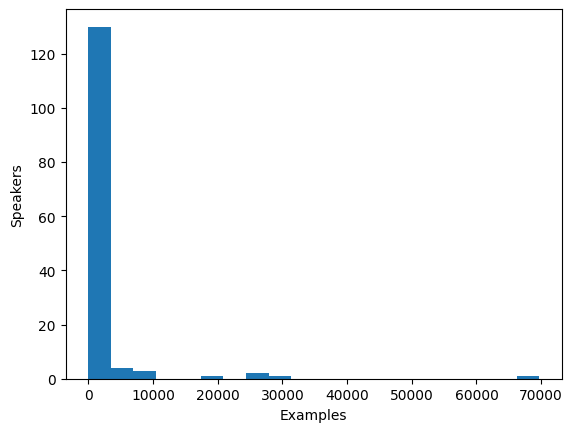

In [ ]:
import matplotlib.pyplot as plt

plt.figure()
plt.hist(speaker_counts.values(), bins=20)
plt.ylabel("Speakers")
plt.xlabel("Examples")
plt.show()

In [ ]:
def select_speaker(speaker_id):
    return 500 <= speaker_counts[speaker_id] <= 5000

dataset = dataset.filter(select_speaker, input_columns=["speaker_id"])


Filter:   0%|          | 0/129106 [00:00<?, ? examples/s]

In [ ]:
len(set(dataset["speaker_id"]))

28

In [ ]:
len(dataset)

38049

In [ ]:
!pip install speechbrain

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 824.8/824.8 kB 19.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 109.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 29.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 54.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 6.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 13.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 88.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 117.7/117.7 kB 11.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

### speaker embedding (512 dimension) using speech brain

In [ ]:
import os
import torch
from speechbrain.pretrained import EncoderClassifier

spk_model_name = "speechbrain/spkrec-xvect-voxceleb"

device = "cuda" if torch.cuda.is_available() else "cpu"
speaker_model = EncoderClassifier.from_hparams(
    source=spk_model_name,
    run_opts={"device": device},
    savedir=os.path.join("/tmp", spk_model_name),
)


def create_speaker_embedding(waveform):
    with torch.no_grad():
        speaker_embeddings = speaker_model.encode_batch(torch.tensor(waveform))
        speaker_embeddings = torch.nn.functional.normalize(speaker_embeddings, dim=2)
        speaker_embeddings = speaker_embeddings.squeeze().cpu().numpy()
    return speaker_embeddings

<ipython-input-10-f28baad2ea60>:3: UserWarning: Module 'speechbrain.pretrained' was deprecated, redirecting to 'speechbrain.inference'. Please update your script. This is a change from SpeechBrain 1.0. See: https://github.com/speechbrain/speechbrain/releases/tag/v1.0.0
  from speechbrain.pretrained import EncoderClassifier


hyperparams.yaml:   0%|          | 0.00/2.04k [00:00<?, ?B/s]

/usr/local/lib/python3.11/dist-packages/speechbrain/utils/autocast.py:68: FutureWarning: `torch.cuda.amp.custom_fwd(args...)` is deprecated. Please use `torch.amp.custom_fwd(args..., device_type='cuda')` instead.
  wrapped_fwd = torch.cuda.amp.custom_fwd(fwd, cast_inputs=cast_inputs)


embedding_model.ckpt:   0%|          | 0.00/16.9M [00:00<?, ?B/s]

mean_var_norm_emb.ckpt:   0%|          | 0.00/3.20k [00:00<?, ?B/s]

classifier.ckpt:   0%|          | 0.00/15.9M [00:00<?, ?B/s]

label_encoder.txt:   0%|          | 0.00/129k [00:00<?, ?B/s]

/usr/local/lib/python3.11/dist-packages/speechbrain/utils/checkpoints.py:200: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = torch.load(path, map_location=device

In [ ]:
{'audio': {'path': '10065_10039_000000.opus',
  'array': array([ 1.23221864e-04,  1.33437061e-04,  1.72911357e-04, ...,
         -1.12180402e-04, -9.45823922e-05,  1.02060207e-04]),
  'sampling_rate': 16000},
 'original_path': 'http://www.archive.org/download/evangilestmarc-lemaistredesacy_1507_librivox/evangilestmarc_09_lemaistredesacy_64kb.mp3',
 'begin_time': 28.64,
 'end_time': 40.34,
 'transcript': "ses vêtements devinrent tout brillants de lumière et blancs comme la neige en sorte qu'il n'y a point de foulon sur la terre qui puisse en faire d'aussi blancs",
 'audio_duration': 11.700000000000005,
 'speaker_id': '10065',
 'chapter_id': '10039',
 'file': '10065_10039_000000.opus',
 'id': '10065_10039_000000',
 'gender': 'male'}

In [ ]:
def prepare_dataset(example):
    audio = example["audio"]

    example = processor(
        text=example["transcription"],
        audio_target=audio["array"],
        sampling_rate=audio["sampling_rate"],
        return_attention_mask=False,
    )

    # strip off the batch dimension
    example["labels"] = example["labels"][0]

    # use SpeechBrain to obtain x-vector
    example["speaker_embeddings"] = create_speaker_embedding(audio["array"])

    return example

In [ ]:
processed_example = prepare_dataset(dataset[0])
list(processed_example.keys())

['input_ids', 'labels', 'speaker_embeddings']

In [ ]:
processed_example["speaker_embeddings"].shape

(512,)

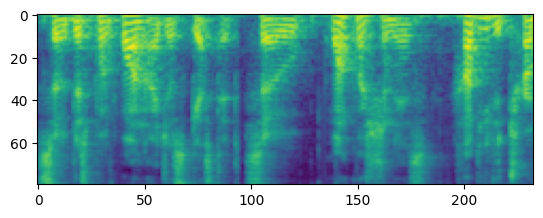

In [ ]:
import matplotlib.pyplot as plt

plt.figure()
plt.imshow(processed_example["labels"].T)
plt.show()

In [ ]:
len(dataset)

26461

In [ ]:
dataset = dataset.shuffle(seed=42).select(range(8000))  # Keep only 10,000 samples


In [ ]:
len(dataset)

8000

In [ ]:
dataset = dataset.map(prepare_dataset, remove_columns=dataset.column_names)

Map:   0%|          | 0/8000 [00:00<?, ? examples/s]

In [ ]:
lengths = [len(x) for x in dataset["input_ids"]]
print(f"Max: {max(lengths)}, Min: {min(lengths)}, Avg: {sum(lengths) / len(lengths)}")


Max: 414, Min: 14, Avg: 209.69475


In [ ]:
def is_not_too_long(input_ids):
    input_length = len(input_ids)
    return input_length < 200


dataset = dataset.filter(is_not_too_long, input_columns=["input_ids"])
len(dataset)

Filter:   0%|          | 0/8000 [00:00<?, ? examples/s]

7977

In [ ]:
dataset = dataset.train_test_split(test_size=0.1)

In [ ]:
from dataclasses import dataclass
from typing import Any, Dict, List, Union


@dataclass
class TTSDataCollatorWithPadding:
    processor: Any

    def __call__(
        self, features: List[Dict[str, Union[List[int], torch.Tensor]]]
    ) -> Dict[str, torch.Tensor]:
        input_ids = [{"input_ids": feature["input_ids"]} for feature in features]
        label_features = [{"input_values": feature["labels"]} for feature in features]
        speaker_features = [feature["speaker_embeddings"] for feature in features]

        # collate the inputs and targets into a batch
        batch = processor.pad(
            input_ids=input_ids, labels=label_features, return_tensors="pt"
        )

        # replace padding with -100 to ignore loss correctly
        batch["labels"] = batch["labels"].masked_fill(
            batch.decoder_attention_mask.unsqueeze(-1).ne(1), -100
        )

        # not used during fine-tuning
        del batch["decoder_attention_mask"]

        # round down target lengths to multiple of reduction factor
        if model.config.reduction_factor > 1:
            target_lengths = torch.tensor(
                [len(feature["input_values"]) for feature in label_features]
            )
            target_lengths = target_lengths.new(
                [
                    length - length % model.config.reduction_factor
                    for length in target_lengths
                ]
            )
            max_length = max(target_lengths)
            batch["labels"] = batch["labels"][:, :max_length]

        # also add in the speaker embeddings
        batch["speaker_embeddings"] = torch.tensor(speaker_features)

        return batch

In [ ]:
data_collator = TTSDataCollatorWithPadding(processor=processor)

In [ ]:
from transformers import SpeechT5ForTextToSpeech

model = SpeechT5ForTextToSpeech.from_pretrained(checkpoint)

config.json:   0%|          | 0.00/2.06k [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/585M [00:00<?, ?B/s]

In [ ]:
from functools import partial

# disable cache during training since it's incompatible with gradient checkpointing
model.config.use_cache = False

# set language and task for generation and re-enable cache
model.generate = partial(model.generate,max_length=200,max_new_tokens=200, use_cache=True)

In [ ]:
len(dataset["train"])

7179

In [ ]:
len(dataset["test"])

800

### training config

In [ ]:
from transformers import Seq2SeqTrainingArguments

training_args = Seq2SeqTrainingArguments(
    output_dir="speecht5_finetuned_custom",
    # Batch size optimizations
    per_device_train_batch_size=4,  # Reduced to prevent OOM errors
    gradient_accumulation_steps=8,  # Increased to compensate for smaller batch size

    # Learning rate schedule
    learning_rate=2e-5,  # Slightly increased for better convergence
    warmup_steps=200,    # Reduced warmup steps
    max_steps=3000,      # Adjusted based on dataset size

    # Memory optimizations
    gradient_checkpointing=True,
    fp16=True,
    optim="adamw_torch",  # More memory efficient optimizer

    # Training monitoring
    evaluation_strategy="steps",
    per_device_eval_batch_size=2,
    save_steps=500,      # More frequent checkpoints
    eval_steps=500,      # More frequent evaluation
    logging_steps=50,    # More frequent logging

    # Save disk space
    save_total_limit=2,  # Keep only the last 2 checkpoints

    # Other optimizations
    report_to=["tensorboard"],
    load_best_model_at_end=True,
    greater_is_better=False,
    label_names=["labels"],
    push_to_hub=True,

    # Additional performance settings
    dataloader_num_workers=2,
    #group_by_length=True,  # Group similar length sequences
    lr_scheduler_type="cosine",  # Cosine learning rate decay
    weight_decay=0.01,    # L2 regularization
)

/usr/local/lib/python3.11/dist-packages/transformers/training_args.py:1575: FutureWarning: `evaluation_strategy` is deprecated and will be removed in version 4.46 of 🤗 Transformers. Use `eval_strategy` instead
  warnings.warn(


In [ ]:
from transformers import Seq2SeqTrainingArguments

training_args = Seq2SeqTrainingArguments(
    output_dir="speecht5_finetuned_voxpopuli_frrr",
    resume_from_checkpoint=True,
    per_device_train_batch_size=16,  # Increased batch size for efficiency
    gradient_accumulation_steps=2,  # Adjusted for memory balance
    learning_rate=2e-5,  # Slightly reduced for stability
    warmup_steps=500,  # More gradual warmup
    max_steps=5000,  # Increased steps for better training
    gradient_checkpointing=True,
    fp16=True,
    evaluation_strategy="steps",
    per_device_eval_batch_size=8,  # Match with training for consistency
    save_steps=1000,  # Save at reasonable intervals
    eval_steps=1000,  # Evaluate less frequently
    logging_steps=100,  # Reduce logging spam
    report_to=["tensorboard"],
    load_best_model_at_end=True,
    greater_is_better=False,
    label_names=["labels"],
    push_to_hub=True,
)


/usr/local/lib/python3.11/dist-packages/transformers/training_args.py:1575: FutureWarning: `evaluation_strategy` is deprecated and will be removed in version 4.46 of 🤗 Transformers. Use `eval_strategy` instead
  warnings.warn(


In [ ]:
from transformers import Seq2SeqTrainer

trainer = Seq2SeqTrainer(
    args=training_args,
    model=model,
    train_dataset=dataset["train"],
    eval_dataset=dataset["test"],
    data_collator=data_collator,
    tokenizer=processor,
)

<ipython-input-27-3e9fd9c3f140>:3: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Seq2SeqTrainer.__init__`. Use `processing_class` instead.
  trainer = Seq2SeqTrainer(


In [ ]:
trainer.train()

Step,Training Loss,Validation Loss
500,4.176500,0.470189
1000,3.980900,0.457411
1500,3.893400,0.451775
2000,3.857400,0.450360
2500,3.753500,0.448055
3000,3.824100,0.447108


/usr/local/lib/python3.11/dist-packages/transformers/modeling_utils.py:2817: UserWarning: Moving the following attributes in the config to the generation config: {'max_length': 1876}. You are seeing this warning because you've set generation parameters in the model config, as opposed to in the generation config.
  warnings.warn(


TrainOutput(global_step=3000, training_loss=4.062655731201172, metrics={'train_runtime': 5270.2016, 'train_samples_per_second': 18.216, 'train_steps_per_second': 0.569, 'total_flos': 7937185730673672.0, 'train_loss': 4.062655731201172, 'epoch': 13.334261838440112})

In [ ]:
trainer.push_to_hub("speecht5_finetuned_custom")

CommitInfo(commit_url='https://huggingface.co/peteparker456/speecht5_finetuned_custom/commit/4362faa565d82893832b3b30ef00bd1f72adad0a', commit_message='speecht5_finetuned_custom', commit_description='', oid='4362faa565d82893832b3b30ef00bd1f72adad0a', pr_url=None, repo_url=RepoUrl('https://huggingface.co/peteparker456/speecht5_finetuned_custom', endpoint='https://huggingface.co', repo_type='model', repo_id='peteparker456/speecht5_finetuned_custom'), pr_revision=None, pr_num=None)

In [ ]:
model = SpeechT5ForTextToSpeech.from_pretrained(
    "peteparker456/speecht5_finetuned_custom"
)

config.json:   0%|          | 0.00/2.10k [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/578M [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/185 [00:00<?, ?B/s]

In [ ]:
example = dataset["test"][10]
speaker_embeddings = torch.tensor(example["speaker_embeddings"]).unsqueeze(0)

In [ ]:
text = "what is your name and Your validation loss is significantly lower than the training loss and Usually, training loss should be lower or close to validation loss."

In [ ]:
inputs = processor(text=text, return_tensors="pt")

In [ ]:
from transformers import SpeechT5HifiGan

vocoder = SpeechT5HifiGan.from_pretrained("microsoft/speecht5_hifigan")
speech = model.generate_speech(inputs["input_ids"], speaker_embeddings, vocoder=vocoder)

In [ ]:
from IPython.display import Audio

Audio(speech.numpy(), rate=16000)